# **Section A: Environment**

In [ ]:
# @title 1 - A1
#Cell 1

# Only install what's missing, don't touch torch/torchvision
!pip uninstall -y fastai
!pip install -q transformers==4.46.3 datasets evaluate scikit-learn accelerate seaborn

import os
os.kill(os.getpid(), 9)

Found existing installation: fastai 2.8.7
Uninstalling fastai-2.8.7:
  Successfully uninstalled fastai-2.8.7
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 116.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 111.2 MB/s eta 0:00:00


# **Section B: Train RiskLens model on SALT-NLP (with group split)**

In [1]:
# @title 3 - B1
from datasets import load_dataset, Dataset
import random

ds_stream = load_dataset("SALT-NLP/search_privacy_risk", split="test", streaming=True)

rows = []
MAX_DIALOGS = 3000
count_dialogs = 0

for ex in ds_stream:
    group_id = f"{ex['example_id']}_{ex['log_id']}"   # keep one convo together
    history = ex["eval"]["history"]

    for h in history:
        details = h.get("details") or {}
        body = details.get("body")

        evaluation = h.get("evaluation") or {}
        label = evaluation.get("label")

        if not body:
            continue

        y = 1 if label == "LEAK" else 0
        rows.append({"text": body, "label": y, "group_id": group_id})

    count_dialogs += 1
    if count_dialogs >= MAX_DIALOGS:
        break

ds_all = Dataset.from_list(rows).shuffle(seed=42)
print(ds_all)
print("Leak count:", sum(ds_all["label"]), "Total:", len(ds_all))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/219 [00:00<?, ?it/s]

Dataset({
    features: ['text', 'label', 'group_id'],
    num_rows: 12031
})
Leak count: 427 Total: 12031


In [2]:
# @title 4 - B2
groups = list(set(ds_all["group_id"]))
random.seed(42)
random.shuffle(groups)

n = len(groups)
train_groups = set(groups[: int(0.8 * n)])
val_groups   = set(groups[int(0.8 * n): int(0.9 * n)])
test_groups  = set(groups[int(0.9 * n):])

def in_groups(example, group_set):
    return example["group_id"] in group_set

ds_train = ds_all.filter(lambda x: in_groups(x, train_groups))
ds_val   = ds_all.filter(lambda x: in_groups(x, val_groups))
ds_test  = ds_all.filter(lambda x: in_groups(x, test_groups))

print("Train:", len(ds_train), "Val:", len(ds_val), "Test:", len(ds_test))
print("Train leak:", sum(ds_train["label"]), "Val leak:", sum(ds_val["label"]), "Test leak:", sum(ds_test["label"]))


Filter:   0%|          | 0/12031 [00:00<?, ? examples/s]

Filter:   0%|          | 0/12031 [00:00<?, ? examples/s]

Filter:   0%|          | 0/12031 [00:00<?, ? examples/s]

Train: 9703 Val: 1391 Test: 937
Train leak: 335 Val leak: 48 Test leak: 44


In [3]:
# @title 5 - B3
import numpy as np
import torch
import evaluate
from collections import Counter
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tok(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

train_tok = ds_train.map(tok, batched=True)
val_tok   = ds_val.map(tok, batched=True)
test_tok  = ds_test.map(tok, batched=True)


train_tok = train_tok.rename_column("label", "labels")
val_tok   = val_tok.rename_column("label", "labels")
test_tok  = test_tok.rename_column("label", "labels")

cols = ["input_ids", "attention_mask", "labels"]
train_tok.set_format(type="torch", columns=cols)
val_tok.set_format(type="torch", columns=cols)
test_tok.set_format(type="torch", columns=cols)

# class weights from TRAIN only
y_train = np.array(ds_train["label"])
counts = Counter(y_train)
neg, pos = counts.get(0, 0), counts.get(1, 0)
w1 = (neg / pos) if pos > 0 else 1.0
class_weights = torch.tensor([1.0, w1], dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        weights = class_weights.to(logits.device)
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

metric_f1 = evaluate.load("f1")
metric_acc = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": metric_acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1": metric_f1.compute(predictions=preds, references=labels)["f1"],
    }

model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

args = TrainingArguments(
    output_dir="risklens_ft",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()
print("Best validation:", trainer.evaluate())


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/937 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.528900,0.459920,0.984184,0.738095
2,0.233500,0.463993,0.983465,0.741573
3,0.153000,0.486607,0.987060,0.795455
4,0.114600,0.596927,0.986341,0.781609
5,0.022800,0.554139,0.988497,0.822222


Best validation: {'eval_loss': 0.5541393756866455, 'eval_accuracy': 0.9884974838245866, 'eval_f1': 0.8222222222222222, 'eval_runtime': 11.4451, 'eval_samples_per_second': 121.536, 'eval_steps_per_second': 7.601, 'epoch': 5.0}


In [4]:
# @title 6 - B4
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
import torch

pred = trainer.predict(test_tok)
logits = pred.predictions
y_true = pred.label_ids

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

precision, recall, thresholds = precision_recall_curve(y_true, probs)
f1_scores = (2 * precision * recall) / (precision + recall + 1e-12)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

y_pred = (probs >= best_threshold).astype(int)

print("Best threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])
print("Precision:", precision[best_idx], "Recall:", recall[best_idx])
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nReport:\n", classification_report(y_true, y_pred, digits=4))
trainer.save_model("risklens_pretrained")
tokenizer.save_pretrained("risklens_pretrained")



Best threshold: 0.08429715
Best F1: 0.9247311827952003
Precision: 0.8775510204081632 Recall: 0.9772727272727273
Confusion Matrix:
 [[887   6]
 [  1  43]]

Report:
               precision    recall  f1-score   support

           0     0.9989    0.9933    0.9961       893
           1     0.8776    0.9773    0.9247        44

    accuracy                         0.9925       937
   macro avg     0.9382    0.9853    0.9604       937
weighted avg     0.9932    0.9925    0.9927       937



('risklens_pretrained/tokenizer_config.json',
 'risklens_pretrained/special_tokens_map.json',
 'risklens_pretrained/vocab.txt',
 'risklens_pretrained/added_tokens.json',
 'risklens_pretrained/tokenizer.json')

# **Section C: Build Enron “cross-domain” dataset (privacy-labeled)**

In [5]:
# @title 8 - C1
from datasets import load_dataset

enron = load_dataset("SetFit/enron_spam")
print(enron)
print(enron["train"][0].keys())
print(enron["train"][0])


README.md:   0%|          | 0.00/176 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/101M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/6.27M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/31716 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['message_id', 'text', 'label', 'label_text', 'subject', 'message', 'date'],
        num_rows: 31716
    })
    test: Dataset({
        features: ['message_id', 'text', 'label', 'label_text', 'subject', 'message', 'date'],
        num_rows: 2000
    })
})
dict_keys(['message_id', 'text', 'label', 'label_text', 'subject', 'message', 'date'])
{'message_id': 33214, 'text': 'any software just for 15 $ - 99 $ understanding oem software\nlead me not into temptation ; i can find the way myself .\n# 3533 . the law disregards trifles .', 'label': 1, 'label_text': 'spam', 'subject': 'any software just for 15 $ - 99 $', 'message': 'understanding oem software\nlead me not into temptation ; i can find the way myself .\n# 3533 . the law disregards trifles .', 'date': datetime.datetime(2005, 6, 18, 0, 0)}


In [6]:
# @title 9 - C2
import re
from datasets import DatasetDict

PHONE_RE = re.compile(r"(\+?\d{1,3}[\s-]?)?(\(?\d{2,4}\)?[\s-]?)?\d{3,4}[\s-]?\d{4}")
EMAIL_RE = re.compile(r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}")
CARD_RE  = re.compile(r"\b(?:\d[ -]*?){13,19}\b")  # rough card-like
BANK_RE  = re.compile(r"\b(account|acct|iban|swift|routing)\b", re.IGNORECASE)
ADDR_RE  = re.compile(r"\b\d{1,5}\s+\w+(?:\s+\w+){0,4}\s+(street|st|road|rd|ave|avenue|lane|ln|blvd|drive|dr)\b", re.IGNORECASE)
ID_RE    = re.compile(r"\b(ssn|nic|passport|national id)\b", re.IGNORECASE)

def is_privacy_leak(text: str) -> int:
    if text is None:
        return 0
    t = text.strip()
    if len(t) < 10:
        return 0
    hits = 0
    hits += 1 if PHONE_RE.search(t) else 0
    hits += 1 if EMAIL_RE.search(t) else 0
    hits += 1 if CARD_RE.search(t) else 0
    hits += 1 if BANK_RE.search(t) else 0
    hits += 1 if ADDR_RE.search(t) else 0
    hits += 1 if ID_RE.search(t) else 0
    return 1 if hits >= 1 else 0  # start simple: any hit means leak

def make_privacy_labels(example):
    txt = example.get("text") or example.get("message") or example.get("email") or ""
    return {"text": txt, "label": is_privacy_leak(txt)}

# Apply on both train and test splits if available
splits = {}
for split in enron.keys():
    splits[split] = enron[split].map(make_privacy_labels)

enron_priv = DatasetDict(splits)
print(enron_priv)
print(enron_priv["train"][0])


Map:   0%|          | 0/31716 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['message_id', 'text', 'label', 'label_text', 'subject', 'message', 'date'],
        num_rows: 31716
    })
    test: Dataset({
        features: ['message_id', 'text', 'label', 'label_text', 'subject', 'message', 'date'],
        num_rows: 2000
    })
})
{'message_id': 33214, 'text': 'any software just for 15 $ - 99 $ understanding oem software\nlead me not into temptation ; i can find the way myself .\n# 3533 . the law disregards trifles .', 'label': 0, 'label_text': 'spam', 'subject': 'any software just for 15 $ - 99 $', 'message': 'understanding oem software\nlead me not into temptation ; i can find the way myself .\n# 3533 . the law disregards trifles .', 'date': datetime.datetime(2005, 6, 18, 0, 0)}


In [7]:
# @title 10 - C3
from collections import Counter
print("Train label counts:", Counter(enron_priv["train"]["label"]))
if "test" in enron_priv:
    print("Test label counts:", Counter(enron_priv["test"]["label"]))


Train label counts: Counter({0: 26014, 1: 5702})
Test label counts: Counter({0: 1680, 1: 320})


In [8]:
# @title 11 - C4
from datasets import DatasetDict

# Make validation split from train
tmp = enron_priv["train"].train_test_split(test_size=0.2, seed=42)
train_ds = tmp["train"]
val_ds   = tmp["test"]

# Use existing test if present, otherwise split from remaining
if "test" in enron_priv:
    test_ds = enron_priv["test"]
else:
    test_ds = val_ds

ds = DatasetDict({"train": train_ds, "validation": val_ds, "test": test_ds})
print(ds)


DatasetDict({
    train: Dataset({
        features: ['message_id', 'text', 'label', 'label_text', 'subject', 'message', 'date'],
        num_rows: 25372
    })
    validation: Dataset({
        features: ['message_id', 'text', 'label', 'label_text', 'subject', 'message', 'date'],
        num_rows: 6344
    })
    test: Dataset({
        features: ['message_id', 'text', 'label', 'label_text', 'subject', 'message', 'date'],
        num_rows: 2000
    })
})


# **Section D - Load SALT-trained model for cross-domain testing**

In [9]:
# @title 12 - D1
from transformers import AutoTokenizer, AutoModelForSequenceClassification

BASE_MODEL_DIR = "risklens_pretrained"  # from Cell B4 save

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_DIR, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL_DIR, local_files_only=True)

print("Loaded SALT-trained model:", BASE_MODEL_DIR)


Loaded SALT-trained model: risklens_pretrained


In [10]:
# @title 13 - D2
from transformers import AutoTokenizer, AutoModelForSequenceClassification

BASE_MODEL_DIR = "risklens_pretrained"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_DIR, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL_DIR, local_files_only=True)

print("Loaded:", BASE_MODEL_DIR)
print("Labels:", model.config.id2label)


Loaded: risklens_pretrained
Labels: {0: 'LABEL_0', 1: 'LABEL_1'}


In [11]:
# @title 14 - D3
def tok(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

tokenized = ds.map(tok, batched=True)
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
print(tokenized)
print(tokenized["train"][0])


Map:   0%|          | 0/25372 [00:00<?, ? examples/s]

Map:   0%|          | 0/6344 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['message_id', 'text', 'labels', 'label_text', 'subject', 'message', 'date', 'input_ids', 'attention_mask'],
        num_rows: 25372
    })
    validation: Dataset({
        features: ['message_id', 'text', 'labels', 'label_text', 'subject', 'message', 'date', 'input_ids', 'attention_mask'],
        num_rows: 6344
    })
    test: Dataset({
        features: ['message_id', 'text', 'labels', 'label_text', 'subject', 'message', 'date', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})
{'labels': tensor(0), 'input_ids': tensor([  101,  3237,  8013,  2862,  2065,  2057,  2064,  4390,  2017,  2320,
         2153,  1010,  3889,  3791,  1010,  2011,  1996,  2203,  1997,  2651,
         1010,  1996,  3415,  1998,  3616,  1997,  1996,  3145, 12706,  2006,
         1996,  2862,  4987,  1012,  3531,  3143,  1996,  2171,  1997,  1996,
         2343,  1010,  3580,  2343,  1998,  3042,  3616,  1012,   102,     0,
            0,     

In [12]:
# @title 15 - D4
import numpy as np
import evaluate
from transformers import TrainingArguments, Trainer

acc = evaluate.load("accuracy")
f1  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1.compute(predictions=preds, references=labels, average="binary")["f1"],
    }

args = TrainingArguments(
    output_dir="risklens_enron_ft",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()
trainer.evaluate()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.182600,0.196005,0.935372,0.814480
2,0.143100,0.151043,0.952711,0.853659
3,0.096600,0.210653,0.943726,0.843900
4,0.044600,0.247576,0.952554,0.861863
5,0.023200,0.272882,0.956179,0.870457


{'eval_loss': 0.2728820741176605,
 'eval_accuracy': 0.9561790668348046,
 'eval_f1': 0.8704566635601119,
 'eval_runtime': 50.8508,
 'eval_samples_per_second': 124.757,
 'eval_steps_per_second': 7.807,
 'epoch': 5.0}

In [13]:
# @title 16 - D5
import numpy as np
import torch
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report

# 1) Get probs on validation
pred_val = trainer.predict(tokenized["validation"])
logits_val = pred_val.predictions
y_val = pred_val.label_ids

probs_val = torch.softmax(torch.tensor(logits_val), dim=1).numpy()[:, 1]

# 2) Find best threshold by F1
precision, recall, thresholds = precision_recall_curve(y_val, probs_val)
f1_scores = (2 * precision * recall) / (precision + recall + 1e-12)

best_idx = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.5

print("Best threshold (by F1 on validation):", best_threshold)
print("Best F1:", float(f1_scores[best_idx]))
print("Precision:", float(precision[best_idx]), "Recall:", float(recall[best_idx]))


Best threshold (by F1 on validation): 0.9850319623947144
Best F1: 0.8750602990829555
Precision: 0.9264555669050051 Recall: 0.8290676416819013


In [14]:
# @title 17 - D6
# Predict on test
pred_test = trainer.predict(tokenized["test"])
logits_test = pred_test.predictions
y_test = pred_test.label_ids

probs_test = torch.softmax(torch.tensor(logits_test), dim=1).numpy()[:, 1]
y_pred = (probs_test >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))


Confusion Matrix:
 [[1662   18]
 [  55  265]]

Classification Report:

              precision    recall  f1-score   support

           0     0.9680    0.9893    0.9785      1680
           1     0.9364    0.8281    0.8789       320

    accuracy                         0.9635      2000
   macro avg     0.9522    0.9087    0.9287      2000
weighted avg     0.9629    0.9635    0.9626      2000



In [48]:
# @title 18 - D7
import os, json
from datetime import datetime

SAVE_DIR = "risklens_enron_generalized"
os.makedirs(SAVE_DIR, exist_ok=True)

trainer.model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

meta = {
    "saved_at": datetime.utcnow().isoformat() + "Z",
    "base_model": "distilbert-base-uncased",
    "fine_tuned_on": "SetFit/enron_spam + rule-based privacy labels",
    "best_threshold_val_f1": best_threshold,
    "val_metrics_last": {
        "eval_accuracy": 0.955233291298865,
        "eval_f1": 0.8614634146341463
    },
    "labels": { "0": "NO_LEAK", "1": "LEAK" },
    "notes": "Threshold tuned on validation split using PR curve F1."
}

meta_path = os.path.join(SAVE_DIR, "risklens_meta.json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print("Saved model + tokenizer to:", SAVE_DIR)
print("Saved meta to:", meta_path)


Saved model + tokenizer to: risklens_enron_generalized
Saved meta to: risklens_enron_generalized/risklens_meta.json


/tmp/ipykernel_13139/808252144.py:12: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "saved_at": datetime.utcnow().isoformat() + "Z",


In [16]:
# @title X1 - Load RiskLens model for XAI
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_DIR = "risklens_enron_generalized"   # change if needed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
    output_attentions=True
)

model.to(device)
model.eval()

print("Loaded model from:", MODEL_DIR)
print("Device:", device)
print("Labels:", model.config.id2label if hasattr(model.config, "id2label") else "No label map found")

Loaded model from: risklens_enron_generalized
Device: cuda
Labels: {0: 'LABEL_0', 1: 'LABEL_1'}


In [17]:
# @title X2 - Improved Explain Prediction (clean tokens)
import numpy as np

def explain_prediction(text, max_length=256, top_k=10):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_length
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)[0]

    pred_idx = int(torch.argmax(probs).item())
    pred_label = "LEAK" if pred_idx == 1 else "NO_LEAK"
    pred_prob = float(probs[pred_idx].item())
    leak_prob = float(probs[1].item())

    # attention
    attentions = outputs.attentions
    last_attn = attentions[-1][0]
    mean_attn = last_attn.mean(dim=0)

    cls_attention = mean_attn[0].detach().cpu().numpy()

    input_ids = inputs["input_ids"][0].detach().cpu().tolist()
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    # merge subwords properly
    words = []
    current_word = ""
    current_score = 0

    for tok, score in zip(tokens, cls_attention):
        if tok in tokenizer.all_special_tokens or tok == "[PAD]":
            continue

        if tok.startswith("##"):
            current_word += tok[2:]
            current_score = max(current_score, score)
        else:
            if current_word:
                words.append((current_word, current_score))
            current_word = tok
            current_score = score

    if current_word:
        words.append((current_word, current_score))

    # clean tokens
    cleaned = []
    for w, s in words:
        if len(w.strip()) < 2:
            continue
        if w.isdigit():
            continue
        cleaned.append((w, float(s)))

    # sort by importance
    cleaned = sorted(cleaned, key=lambda x: x[1], reverse=True)

    return {
        "text": text,
        "prediction": pred_label,
        "prediction_probability": pred_prob,
        "leak_probability": leak_prob,
        "top_important_words": cleaned[:top_k]
    }

In [39]:
# @title X6 - Refined Hybrid XAI (fixed attention)
import re
import torch

STOPWORDS = {
    "and", "is", "my", "the", "a", "an", "of", "to", "for", "at", "in", "on",
    "are", "was", "were", "be", "been", "being", "let", "pm", "am", "it", "this"
}

PHONE_RE = re.compile(r"\b(?:\+?\d{1,3}[- ]?)?(?:\d{10}|\d{3}[- ]\d{3}[- ]\d{4})\b")
EMAIL_RE = re.compile(r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}")
CARD_RE  = re.compile(r"\b(?:\d[ -]*?){13,19}\b")
BANK_RE  = re.compile(r"\b(account|acct|iban|swift|routing|bank)\b", re.IGNORECASE)
ADDR_RE  = re.compile(r"\b\d{1,5}\s+\w+(?:\s+\w+){0,4}\s+(street|st|road|rd|ave|avenue|lane|ln|blvd|drive|dr)\b", re.IGNORECASE)
ID_RE    = re.compile(r"\b(?:\d{12}|ssn|nic|passport|national id)\b", re.IGNORECASE)

def detect_sensitive_entities_refined(text):
    entities = []

    if ID_RE.search(text):
        entities.append("ID_INFO")
    if EMAIL_RE.search(text):
        entities.append("EMAIL")
    if BANK_RE.search(text):
        entities.append("BANK_INFO")
    if ADDR_RE.search(text):
        entities.append("ADDRESS")
    if CARD_RE.search(text):
        entities.append("CARD_NUMBER")
    if PHONE_RE.search(text) and "ID_INFO" not in entities:
        entities.append("PHONE")

    return entities

def explain_prediction_refined(text, max_length=256, top_k=10):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_length
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)[0]

    pred_idx = int(torch.argmax(probs).item())
    pred_label = "LEAK" if pred_idx == 1 else "NO_LEAK"
    pred_prob = float(probs[pred_idx].item())
    leak_prob = float(probs[1].item())

    top_words = []
    if outputs.attentions is not None:
        last_attn = outputs.attentions[-1][0]      # [heads, seq_len, seq_len]
        mean_attn = last_attn.mean(dim=0)          # [seq_len, seq_len]
        cls_attention = mean_attn[0].detach().cpu().numpy()

        input_ids = inputs["input_ids"][0].detach().cpu().tolist()
        tokens = tokenizer.convert_ids_to_tokens(input_ids)

        words = []
        current_word = ""
        current_score = 0

        for tok, score in zip(tokens, cls_attention):
            if tok in tokenizer.all_special_tokens or tok == "[PAD]":
                continue

            if tok.startswith("##"):
                current_word += tok[2:]
                current_score = max(current_score, score)
            else:
                if current_word:
                    words.append((current_word, current_score))
                current_word = tok
                current_score = score

        if current_word:
            words.append((current_word, current_score))

        cleaned = []
        seen = set()

        for w, s in words:
            w = w.lower().strip()
            if len(w) < 2:
                continue
            if w in STOPWORDS:
                continue
            if w.isdigit():
                continue
            if w in seen:
                continue
            seen.add(w)
            cleaned.append((w, float(s)))

        cleaned = sorted(cleaned, key=lambda x: x[1], reverse=True)
        top_words = cleaned[:top_k]

    entities = detect_sensitive_entities_refined(text)

    reasons = []
    if entities:
        reasons.append("explicit sensitive patterns detected: " + ", ".join(entities))
    if top_words:
        reasons.append("model focused on words such as: " + ", ".join([w for w, _ in top_words[:5]]))

    if pred_label == "LEAK":
        explanation = f"This text is classified as LEAK with probability {leak_prob:.4f}."
    else:
        explanation = f"This text is classified as NO_LEAK with probability {1 - leak_prob:.4f}."

    if reasons:
        explanation += " Main reasons: " + " | ".join(reasons)

    return {
        "text": text,
        "prediction": pred_label,
        "prediction_probability": pred_prob,
        "leak_probability": leak_prob,
        "detected_entities": entities,
        "top_important_words": top_words,
        "explanation": explanation
    }

In [40]:
# @title X7 - Test refined hybrid XAI
samples = [
    "My phone number is 0771234567 and my email is wishma@gmail.com.",
    "Let's schedule the team meeting for tomorrow at 3 PM.",
    "My NIC is 200112345678 and my bank account details are attached."
]

for i, s in enumerate(samples, 1):
    result = explain_prediction_refined(s, top_k=8)

    print(f"\n--- Sample {i} ---")
    print("Text:", result["text"])
    print("Prediction:", result["prediction"])
    print("Prediction Probability:", round(result["prediction_probability"], 4))
    print("Leak Probability:", round(result["leak_probability"], 4))
    print("Detected Entities:", result["detected_entities"])
    print("Top Important Words:")
    for tok, score in result["top_important_words"]:
        print(f"  {tok}: {score:.4f}")
    print("Explanation:", result["explanation"])


--- Sample 1 ---
Text: My phone number is 0771234567 and my email is wishma@gmail.com.
Prediction: LEAK
Prediction Probability: 1.0
Leak Probability: 1.0
Detected Entities: ['EMAIL', 'PHONE']
Top Important Words:
  number: 0.0004
  phone: 0.0002
  com: 0.0001
  gmail: 0.0000
  wishma: 0.0000
  email: 0.0000
Explanation: This text is classified as LEAK with probability 1.0000. Main reasons: explicit sensitive patterns detected: EMAIL, PHONE | model focused on words such as: number, phone, com, gmail, wishma

--- Sample 2 ---
Text: Let's schedule the team meeting for tomorrow at 3 PM.
Prediction: NO_LEAK
Prediction Probability: 1.0
Leak Probability: 0.0
Detected Entities: []
Top Important Words:
  team: 0.0253
  tomorrow: 0.0054
  schedule: 0.0043
  meeting: 0.0020
Explanation: This text is classified as NO_LEAK with probability 1.0000. Main reasons: model focused on words such as: team, tomorrow, schedule, meeting

--- Sample 3 ---
Text: My NIC is 200112345678 and my bank account detai

In [20]:
# @title X8 - Backend-ready XAI response
def get_risklens_response(text):
    result = explain_prediction_refined(text, top_k=8)

    return {
        "input_text": result["text"],
        "prediction": result["prediction"],
        "prediction_probability": round(result["prediction_probability"], 4),
        "leak_probability": round(result["leak_probability"], 4),
        "detected_entities": result["detected_entities"],
        "top_important_words": [w for w, _ in result["top_important_words"]],
        "explanation": result["explanation"]
    }

In [21]:
# @title X9 - Test backend-ready output
sample_text = "My NIC is 200112345678 and my bank account details are attached."
response = get_risklens_response(sample_text)
response

{'input_text': 'My NIC is 200112345678 and my bank account details are attached.',
 'prediction': 'LEAK',
 'prediction_probability': 1.0,
 'leak_probability': 1.0,
 'detected_entities': ['ID_INFO', 'BANK_INFO'],
 'top_important_words': ['nic', 'details', 'account', 'bank', 'attached'],
 'explanation': 'This text is classified as LEAK with probability 1.0000. Main reasons: explicit sensitive patterns detected: ID_INFO, BANK_INFO | model focused on words such as: nic, details, account, bank, attached'}

In [41]:
# @title X10 - Recommendation engine integrated with hybrid XAI

def generate_recommendations(prediction, entities, text):
    recommendations = []

    if prediction == "NO_LEAK":
        recommendations.append("No critical privacy risk detected. Review the text once before sharing.")
        return recommendations

    if "PHONE" in entities:
        recommendations.append("Mask or remove the phone number before sharing.")
    if "EMAIL" in entities:
        recommendations.append("Replace the personal email address with a placeholder or generic contact.")
    if "BANK_INFO" in entities:
        recommendations.append("Avoid sharing banking or account-related information in plain text.")
    if "ID_INFO" in entities:
        recommendations.append("Remove or partially mask national ID, NIC, passport, or similar identifiers.")
    if "ADDRESS" in entities:
        recommendations.append("Avoid sharing exact address details unless absolutely necessary.")
    if "CARD_NUMBER" in entities:
        recommendations.append("Do not share card-like numbers in unprotected text.")

    # fallback recommendation if model predicts leak but regex found nothing
    if not entities:
        recommendations.append("Review the text and remove any personal or sensitive information before sharing.")
        recommendations.append("Consider replacing real details with masked or dummy values.")

    return recommendations


def hybrid_explain_with_recommendation(text, top_k=8):
    result = explain_prediction_refined(text, top_k=top_k)

    recommendations = generate_recommendations(
        prediction=result["prediction"],
        entities=result["detected_entities"],
        text=text
    )

    return {
        "text": result["text"],
        "prediction": result["prediction"],
        "prediction_probability": result["prediction_probability"],
        "leak_probability": result["leak_probability"],
        "detected_entities": result["detected_entities"],
        "top_important_words": result["top_important_words"],
        "explanation": result["explanation"],
        "recommendations": recommendations
    }

In [42]:
# @title X11 - Test recommendation engine
samples = [
    "My phone number is 0771234567 and my email is wishma@gmail.com.",
    "Let's schedule the team meeting for tomorrow at 3 PM.",
    "My NIC is 200112345678 and my bank account details are attached."
]

for i, s in enumerate(samples, 1):
    result = hybrid_explain_with_recommendation(s, top_k=8)

    print(f"\n--- Sample {i} ---")
    print("Text:", result["text"])
    print("Prediction:", result["prediction"])
    print("Prediction Probability:", round(result["prediction_probability"], 4))
    print("Leak Probability:", round(result["leak_probability"], 4))
    print("Detected Entities:", result["detected_entities"])
    print("Top Important Words:")
    for tok, score in result["top_important_words"]:
        print(f"  {tok}: {score:.4f}")
    print("Explanation:", result["explanation"])
    print("Recommendations:")
    for rec in result["recommendations"]:
        print(" -", rec)


--- Sample 1 ---
Text: My phone number is 0771234567 and my email is wishma@gmail.com.
Prediction: LEAK
Prediction Probability: 1.0
Leak Probability: 1.0
Detected Entities: ['EMAIL', 'PHONE']
Top Important Words:
  number: 0.0004
  phone: 0.0002
  com: 0.0001
  gmail: 0.0000
  wishma: 0.0000
  email: 0.0000
Explanation: This text is classified as LEAK with probability 1.0000. Main reasons: explicit sensitive patterns detected: EMAIL, PHONE | model focused on words such as: number, phone, com, gmail, wishma
Recommendations:
 - Mask or remove the phone number before sharing.
 - Replace the personal email address with a placeholder or generic contact.

--- Sample 2 ---
Text: Let's schedule the team meeting for tomorrow at 3 PM.
Prediction: NO_LEAK
Prediction Probability: 1.0
Leak Probability: 0.0
Detected Entities: []
Top Important Words:
  team: 0.0253
  tomorrow: 0.0054
  schedule: 0.0043
  meeting: 0.0020
Explanation: This text is classified as NO_LEAK with probability 1.0000. Main re

In [22]:
# @title L1 - Install LIME
!pip -q install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [23]:
# @title L2 - Load saved model and define LIME prediction function
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_DIR = "risklens_enron_generalized"   # change if needed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR, local_files_only=True)
model.to(device)
model.eval()

def predict_proba_lime(texts):
    """
    texts: list of strings
    returns: numpy array of shape [n_samples, 2]
             columns = [NO_LEAK probability, LEAK probability]
    """
    enc = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        outputs = model(**enc)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()

    return probs

print("Model loaded for LIME.")

Model loaded for LIME.


In [24]:
# @title L3 - Generate LIME explanation
from lime.lime_text import LimeTextExplainer

class_names = ["NO_LEAK", "LEAK"]
explainer = LimeTextExplainer(class_names=class_names)

sample_text = "My phone number is 0771234567 and my email is wishma@gmail.com."

exp = explainer.explain_instance(
    sample_text,
    predict_proba_lime,
    num_features=10,
    num_samples=1000
)

print("Predicted probabilities:", predict_proba_lime([sample_text])[0])
print("\nTop features for predicted class:\n")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

Predicted probabilities: [3.5173642e-05 9.9996483e-01]

Top features for predicted class:

0771234567: 0.9891
com: 0.0013
is: 0.0012
gmail: 0.0011
phone: 0.0006
email: 0.0006
My: 0.0006
wishma: 0.0005
and: 0.0004
my: 0.0001


In [26]:
# @title L4A - Show LIME explanation in notebook
exp.show_in_notebook(text=True)

AUC Score: 0.9005395500356307


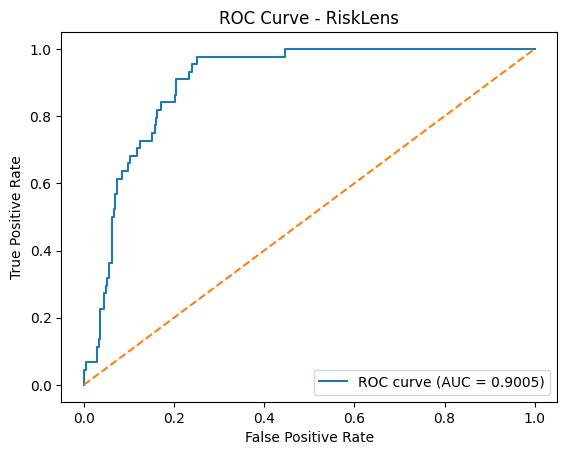

In [27]:
# @title X10 - ROC Curve & AUC
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# get predictions from test set
pred = trainer.predict(test_tok)
logits = pred.predictions
y_true = pred.label_ids

# convert logits → probabilities (for class 1 = LEAK)
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

# compute ROC
fpr, tpr, thresholds = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RiskLens")
plt.legend(loc="lower right")
plt.show()

     loss  grad_norm  learning_rate     epoch  step  eval_loss  eval_accuracy  \
0  0.3020   1.068548       0.000019  0.315259   500        NaN            NaN   
1  0.1953   4.007330       0.000017  0.630517  1000        NaN            NaN   
2  0.1826   3.138983       0.000016  0.945776  1500        NaN            NaN   
3     NaN        NaN            NaN  1.000000  1586   0.196005       0.935372   
4  0.1508   0.188937       0.000015  1.261034  2000        NaN            NaN   

   eval_f1  eval_runtime  eval_samples_per_second  eval_steps_per_second  \
0      NaN           NaN                      NaN                    NaN   
1      NaN           NaN                      NaN                    NaN   
2      NaN           NaN                      NaN                    NaN   
3  0.81448       50.7872                  124.913                  7.817   
4      NaN           NaN                      NaN                    NaN   

   train_runtime  train_samples_per_second  train_steps_

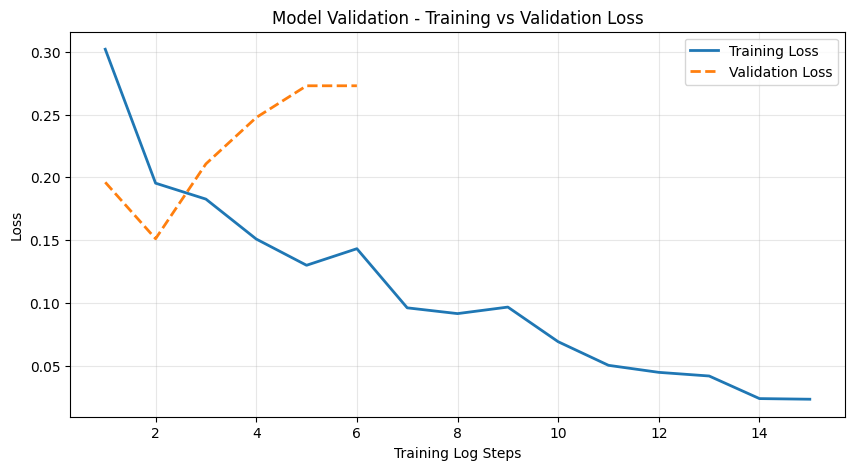

In [31]:
# @title X11 - Training vs Validation Loss Curve
import matplotlib.pyplot as plt
import pandas as pd

log_df = pd.DataFrame(trainer.state.log_history)
print(log_df.head())

# training loss logs
train_logs = log_df[log_df["loss"].notna()].copy()
train_logs["x"] = range(1, len(train_logs) + 1)

# validation loss logs
val_logs = log_df[log_df["eval_loss"].notna()].copy()
val_logs["x"] = range(1, len(val_logs) + 1)

plt.figure(figsize=(10, 5))
plt.plot(train_logs["x"], train_logs["loss"], label="Training Loss", linewidth=2)
plt.plot(val_logs["x"], val_logs["eval_loss"], label="Validation Loss", linestyle="--", linewidth=2)

plt.title("Model Validation - Training vs Validation Loss")
plt.xlabel("Training Log Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

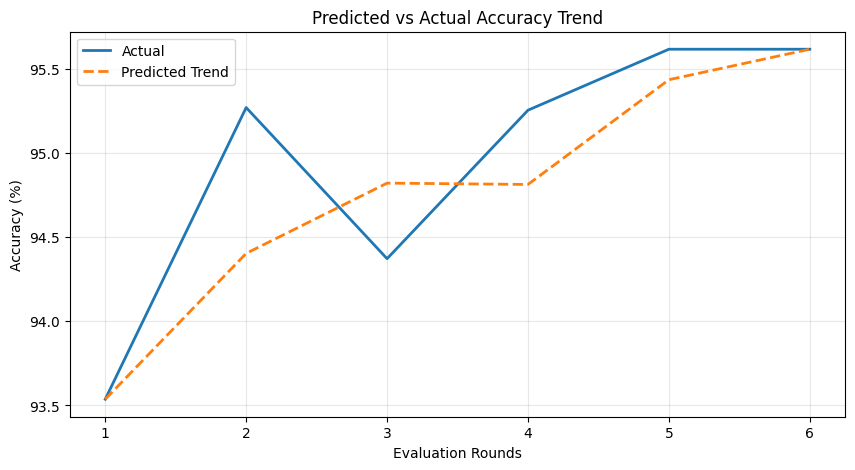

In [33]:
# @title X13 - Smoothed Accuracy Trend Curve
import matplotlib.pyplot as plt
import pandas as pd

log_df = pd.DataFrame(trainer.state.log_history)
val_acc_logs = log_df[log_df["eval_accuracy"].notna()].copy().reset_index(drop=True)

val_acc_logs["round"] = range(1, len(val_acc_logs) + 1)
val_acc_logs["actual"] = val_acc_logs["eval_accuracy"] * 100
val_acc_logs["smoothed"] = val_acc_logs["actual"].rolling(window=2, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.plot(val_acc_logs["round"], val_acc_logs["actual"], label="Actual", linewidth=2)
plt.plot(val_acc_logs["round"], val_acc_logs["smoothed"], label="Predicted Trend", linestyle="--", linewidth=2)

plt.title("Predicted vs Actual Accuracy Trend")
plt.xlabel("Evaluation Rounds")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# **Part B: NER Module using WNUT-2017**

In [43]:
# @title N1 - Load pretrained WNUT-2017 NER model
!pip -q install transformers torch

import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

NER_MODEL_NAME = "tner/bertweet-large-wnut2017"

device = 0 if torch.cuda.is_available() else -1

ner_tokenizer = AutoTokenizer.from_pretrained(NER_MODEL_NAME)
ner_model = AutoModelForTokenClassification.from_pretrained(NER_MODEL_NAME)

ner_pipe = pipeline(
    "token-classification",
    model=ner_model,
    tokenizer=ner_tokenizer,
    aggregation_strategy="simple",
    device=device
)

print("Loaded NER model:", NER_MODEL_NAME)
print("Device:", "GPU" if device == 0 else "CPU")

tokenizer_config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loaded NER model: tner/bertweet-large-wnut2017
Device: GPU


In [44]:
# @title N2 - Extract named entities from text
def extract_wnut_entities(text):
    raw_entities = ner_pipe(text)

    cleaned_entities = []
    for ent in raw_entities:
        cleaned_entities.append({
            "entity_group": ent.get("entity_group"),
            "word": ent.get("word"),
            "score": round(float(ent.get("score", 0.0)), 4),
            "start": ent.get("start"),
            "end": ent.get("end")
        })

    return cleaned_entities


def print_wnut_entities(text):
    entities = extract_wnut_entities(text)

    print("Text:", text)
    print("Detected Named Entities:")
    if not entities:
        print("  None")
    else:
        for ent in entities:
            print(
                f"  {ent['word']} | Type: {ent['entity_group']} | "
                f"Score: {ent['score']} | Span: ({ent['start']}, {ent['end']})"
            )

In [45]:
# @title N3 - Test pretrained WNUT-2017 NER
samples = [
    "My phone number is 0771234567 and my email is wishma@gmail.com.",
    "Let's schedule the team meeting for tomorrow at 3 PM.",
    "My NIC is 200112345678 and my bank account details are attached.",
    "John from Microsoft will visit Colombo next week.",
    "Please send the report to Kavindi at IIT."
]

for i, s in enumerate(samples, 1):
    print(f"\n--- Sample {i} ---")
    print_wnut_entities(s)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



--- Sample 1 ---
Text: My phone number is 0771234567 and my email is wishma@gmail.com.
Detected Named Entities:
  None

--- Sample 2 ---
Text: Let's schedule the team meeting for tomorrow at 3 PM.
Detected Named Entities:
  None

--- Sample 3 ---
Text: My NIC is 200112345678 and my bank account details are attached.
Detected Named Entities:
  None

--- Sample 4 ---
Text: John from Microsoft will visit Colombo next week.
Detected Named Entities:
  John | Type: person | Score: 0.9952 | Span: (0, 4)
   Microsoft | Type: corporation | Score: 0.9001 | Span: (10, 19)
   Colombo | Type: location | Score: 0.9953 | Span: (31, 38)

--- Sample 5 ---
Text: Please send the report to Kavindi at IIT.
Detected Named Entities:
   Kavindi | Type: person | Score: 0.9916 | Span: (26, 33)
   IIT | Type: location | Score: 0.8585 | Span: (37, 40)


In [46]:
# @title N4 - Hybrid XAI + NER integration

def hybrid_full_explain(text, top_k=8):
    base = hybrid_explain_with_recommendation(text, top_k=top_k)

    ner_entities = extract_wnut_entities(text)

    # keep only useful ones
    filtered_ner = []
    for ent in ner_entities:
        if ent["entity_group"] in ["person", "location", "corporation"]:
            filtered_ner.append(ent)

    base["ner_entities"] = filtered_ner

    return base

In [47]:
# @title N5 - Test full hybrid system

samples = [
    "My phone number is 0771234567 and my email is wishma@gmail.com.",
    "John from Microsoft will visit Colombo next week.",
    "My NIC is 200112345678 and my bank account details are attached.",
    "Please contact Kavindi at IIT regarding the meeting."
]

for i, s in enumerate(samples, 1):
    result = hybrid_full_explain(s)

    print(f"\n--- Sample {i} ---")
    print("Text:", result["text"])
    print("Prediction:", result["prediction"])
    print("Detected Privacy Entities:", result["detected_entities"])
    print("Detected Named Entities (NER):")

    if not result["ner_entities"]:
        print("  None")
    else:
        for ent in result["ner_entities"]:
            print(f"  {ent['word']} ({ent['entity_group']})")

    print("Explanation:", result["explanation"])
    print("Recommendations:")
    for rec in result["recommendations"]:
        print(" -", rec)


--- Sample 1 ---
Text: My phone number is 0771234567 and my email is wishma@gmail.com.
Prediction: LEAK
Detected Privacy Entities: ['EMAIL', 'PHONE']
Detected Named Entities (NER):
  None
Explanation: This text is classified as LEAK with probability 1.0000. Main reasons: explicit sensitive patterns detected: EMAIL, PHONE | model focused on words such as: number, phone, com, gmail, wishma
Recommendations:
 - Mask or remove the phone number before sharing.
 - Replace the personal email address with a placeholder or generic contact.

--- Sample 2 ---
Text: John from Microsoft will visit Colombo next week.
Prediction: NO_LEAK
Detected Privacy Entities: []
Detected Named Entities (NER):
  John (person)
   Microsoft (corporation)
   Colombo (location)
Explanation: This text is classified as NO_LEAK with probability 1.0000. Main reasons: model focused on words such as: john, colombo, will, microsoft, visit
Recommendations:
 - No critical privacy risk detected. Review the text once before sha